## Data analysis notebook for business question 1
### **Business question:** are there significant gaps bewteen the overall test score between public and private schools?

In [32]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf



In [17]:
# load data
df = pd.read_csv("../../clean_data/filtered_icfes_data.csv")

In [18]:
# 1. Data overview
print("=" * 80)
print("1. DATASET OVERVIEW")
print("=" * 80)
print(f"\nDataset shape: {df.shape}")
print(f"\nColumn names and types:\n{df.dtypes}") # We could cast dane and period to str but not a deal breaker
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nSchool type distribution:\n{df['cole_naturaleza'].value_counts()}")
print(f"\nGlobal score statistics:\n{df['punt_global'].describe()}")

1. DATASET OVERVIEW

Dataset shape: (77575, 17)

Column names and types:
periodo                       int64
estu_consecutivo                str
cole_area_ubicacion             str
cole_calendario                 str
cole_cod_dane_sede            int64
cole_jornada                    str
cole_naturaleza                 str
cole_nombre_sede                str
fami_educacionmadre             str
fami_educacionpadre             str
desemp_ingles                   str
punt_ingles                 float64
punt_matematicas            float64
punt_sociales_ciudadanas    float64
punt_c_naturales            float64
punt_lectura_critica        float64
punt_global                 float64
dtype: object

Missing values:
periodo                        0
estu_consecutivo               0
cole_area_ubicacion            0
cole_calendario                0
cole_cod_dane_sede             0
cole_jornada                   0
cole_naturaleza                0
cole_nombre_sede               0
fami_educacionmadre 

In [19]:
# 2. Descriptive stats by school type
print("\n" + "=" * 80)
print("2. DESCRIPTIVE STATISTICS BY SCHOOL TYPE")
print("=" * 80)

# Overall statistics (instead of just using .describe() which doesn't give us IQR we manually compute the stats)
official_scores = df[df['cole_naturaleza'] == 'OFICIAL']['punt_global']
non_official_scores = df[df['cole_naturaleza'] == 'NO OFICIAL']['punt_global']

print(f"\n--- PUBLIC SCHOOLS ---")
print(f"Count: {len(official_scores)}")
print(f"Mean: {official_scores.mean():.2f}")
print(f"Median: {official_scores.median():.2f}")
print(f"Std Dev: {official_scores.std():.2f}")
print(f"Min: {official_scores.min():.2f}")
print(f"Max: {official_scores.max():.2f}")
print(f"Q1 (25%): {official_scores.quantile(0.25):.2f}")
print(f"Q3 (75%): {official_scores.quantile(0.75):.2f}")
print(f"IQR: {official_scores.quantile(0.75) - official_scores.quantile(0.25):.2f}")

print(f"\n--- PRIVATE SCHOOLS ---")
print(f"Count: {len(non_official_scores)}")
print(f"Mean: {non_official_scores.mean():.2f}")
print(f"Median: {non_official_scores.median():.2f}")
print(f"Std Dev: {non_official_scores.std():.2f}")
print(f"Min: {non_official_scores.min():.2f}")
print(f"Max: {non_official_scores.max():.2f}")
print(f"Q1 (25%): {non_official_scores.quantile(0.25):.2f}")
print(f"Q3 (75%): {non_official_scores.quantile(0.75):.2f}")
print(f"IQR: {non_official_scores.quantile(0.75) - non_official_scores.quantile(0.25):.2f}")

print(f"\n--- COMPARISON ---")
print(f"Difference in means: {non_official_scores.mean() - official_scores.mean():.2f}")
print(f"Difference in medians: {non_official_scores.median() - official_scores.median():.2f}")



2. DESCRIPTIVE STATISTICS BY SCHOOL TYPE

--- PUBLIC SCHOOLS ---
Count: 63075
Mean: 239.65
Median: 236.00
Std Dev: 41.53
Min: 18.00
Max: 465.00
Q1 (25%): 209.00
Q3 (75%): 267.00
IQR: 58.00

--- PRIVATE SCHOOLS ---
Count: 14500
Mean: 257.20
Median: 252.00
Std Dev: 59.22
Min: 0.00
Max: 465.00
Q1 (25%): 210.00
Q3 (75%): 302.00
IQR: 92.00

--- COMPARISON ---
Difference in means: 17.54
Difference in medians: 16.00


In [20]:
# 3. Subject scores stats
print("\n" + "=" * 80)
print("3. SUBJECT SCORES STATISTICS BY SCHOOL TYPE")
print("=" * 80)

subject_columns = ['punt_ingles', 'punt_matematicas', 'punt_sociales_ciudadanas', 
                   'punt_c_naturales', 'punt_lectura_critica']

comparison_stats = pd.DataFrame()

for subject in subject_columns:
    official_subject = df[df['cole_naturaleza'] == 'OFICIAL'][subject]
    non_official_subject = df[df['cole_naturaleza'] == 'NO OFICIAL'][subject]
    
    comparison_stats[subject] = [
        f"{official_subject.mean():.2f}",
        f"{non_official_subject.mean():.2f}",
        f"{non_official_subject.mean() - official_subject.mean():.2f}"
    ]

comparison_stats.index = ['Public Mean', 'Private Mean', 'Difference (Private - Public)']
print(f"\n{comparison_stats}")


3. SUBJECT SCORES STATISTICS BY SCHOOL TYPE

                              punt_ingles punt_matematicas  \
Public Mean                         46.67            48.05   
Private Mean                        53.61            51.17   
Difference (Private - Public)        6.93             3.12   

                              punt_sociales_ciudadanas punt_c_naturales  \
Public Mean                                      46.47            48.14   
Private Mean                                     49.94            51.19   
Difference (Private - Public)                     3.48             3.05   

                              punt_lectura_critica  
Public Mean                                  49.48  
Private Mean                                 52.73  
Difference (Private - Public)                 3.25  


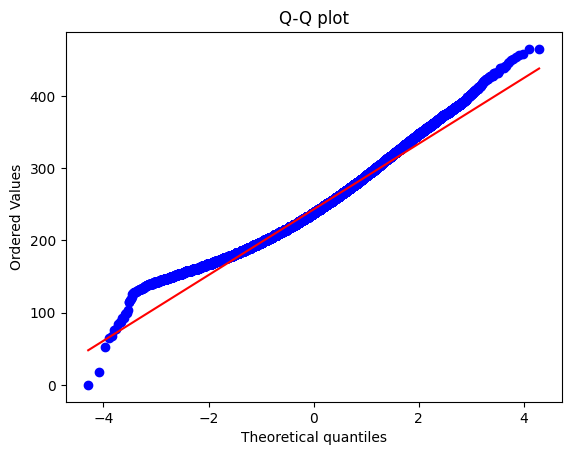

In [21]:
# 4. Stat tests
# 4.0 QQ plot
stats.probplot(df['punt_global'], dist="norm", plot=plt)
plt.title("Q-Q plot")
plt.show()

In [22]:
print("\n" + "=" * 80)
print("4. STATISTICAL SIGNIFICANCE TESTS")
print("=" * 80)

# 4.1 Levene's Test for Equal Variances
print(f"\n4.1 Levene's Test for Equal Variances:")
_, p_levene = stats.levene(official_scores, non_official_scores)
print(f"p-value: {p_levene:.4f} - {'EQUAL VARIANCES' if p_levene > 0.05 else 'UNEQUAL VARIANCES'}")

# 4.2 Independent t-test
print(f"\n4.2 Independent t-test (Parametric):")
t_stat, p_ttest = stats.ttest_ind(official_scores, non_official_scores)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_ttest:.4e} - {'SIGNIFICANT' if p_ttest < 0.05 else 'NOT SIGNIFICANT'} at \\alpha=0.05")

# 4.3 Mann-Whitney U Test 
print(f"\n4.3 Mann-Whitney U Test (Non-parametric):")
u_stat, p_mw = stats.mannwhitneyu(official_scores, non_official_scores, alternative='two-sided')
print(f"U-statistic: {u_stat:.4f}")
print(f"p-value: {p_mw:.4e} - {'SIGNIFICANT' if p_mw < 0.05 else 'NOT SIGNIFICANT'} at \\alpha=0.05")

print(f"\n4.4 CONCLUSION:")
print(f"There are statistically significant differences between official and non-official schools" 
      if p_mw < 0.05 else "There are no statistically significant differences")


4. STATISTICAL SIGNIFICANCE TESTS

4.1 Levene's Test for Equal Variances:
p-value: 0.0000 - UNEQUAL VARIANCES

4.2 Independent t-test (Parametric):
t-statistic: -41.9921
p-value: 0.0000e+00 - SIGNIFICANT at \alpha=0.05

4.3 Mann-Whitney U Test (Non-parametric):
U-statistic: 385036045.5000
p-value: 4.5916e-194 - SIGNIFICANT at \alpha=0.05

4.4 CONCLUSION:
There are statistically significant differences between official and non-official schools


In [40]:
# 4.5 OLS Regression

print("\n" + "=" * 80)
print("4.5 OLS")
print("=" * 80)

# Run OLS regression with categorical treatment (OFICIAL as reference)
modelo = smf.ols("""
punt_global ~ C(cole_naturaleza, Treatment(reference="OFICIAL"))
""", data=df).fit(cov_type="HC3")

# Display results
print("\n" + modelo.summary().as_text())

# Extract coefficient for private
coef_no_oficial = modelo.params.iloc[1] 
p_value = modelo.pvalues.iloc[1]
intercept = modelo.params.iloc[0]

print("\n" + "=" * 80)
print("INTERPRETATION:")
print("=" * 80)
print(f"\nIntercept (OFICIAL Schools Mean): {intercept:.2f} points")
print(f"Coefficient (NO OFICIAL Effect): {coef_no_oficial:+.2f} points")
print(f"P-value: {p_value:.4e}")
print(f"\nInterpretation: NO OFICIAL (private) schools have a {coef_no_oficial:+.2f} point difference")
print(f"in global test scores compared to OFICIAL (public) schools.")
print(f"This effect is {'STATISTICALLY SIGNIFICANT' if p_value < 0.05 else 'NOT statistically significant'} at \\alpha=0.05")
print(f"\nR-squared: {modelo.rsquared:.4f} (School type explains {modelo.rsquared*100:.2f}% of variation in scores)")


4.5 OLS

                            OLS Regression Results                            
Dep. Variable:            punt_global   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     1143.
Date:                Fri, 27 Feb 2026   Prob (F-statistic):          9.09e-249
Time:                        19:09:33   Log-Likelihood:            -4.0600e+05
No. Observations:               77575   AIC:                         8.120e+05
Df Residuals:                   77573   BIC:                         8.120e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                                                                       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

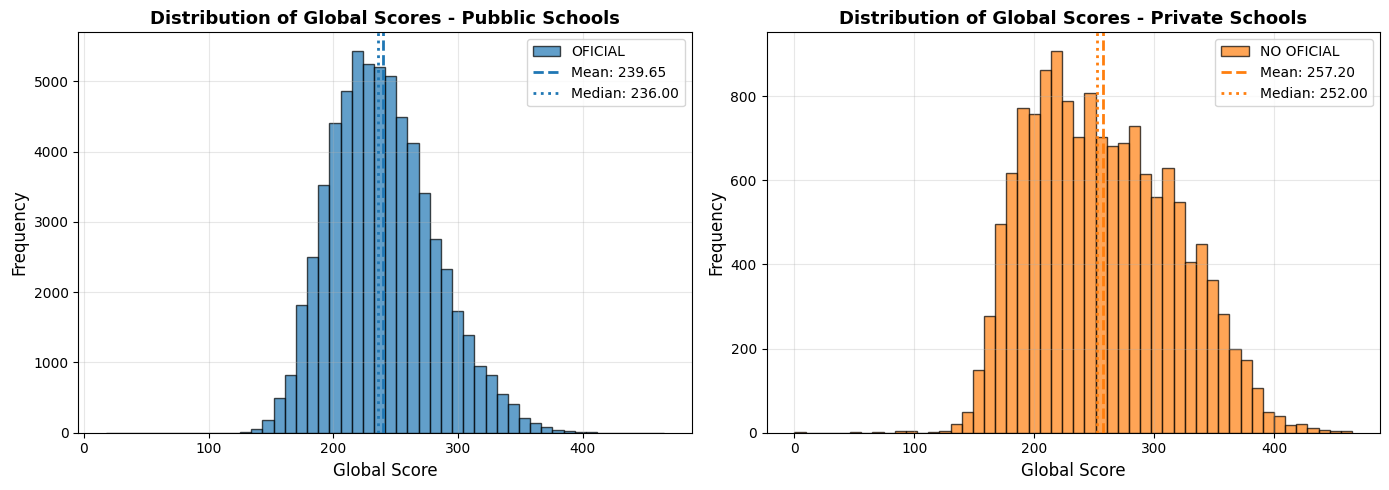

Figure 1: Histograms showing the distribution of global scores by school type.


In [23]:
# 5. Histograms - Dist of Global Scores (with help from Copilot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(official_scores, bins=50, alpha=0.7, label='OFICIAL', color='#1f77b4', edgecolor='black')
axes[0].axvline(official_scores.mean(), color='#1f77b4', linestyle='--', linewidth=2, label=f'Mean: {official_scores.mean():.2f}')
axes[0].axvline(official_scores.median(), color='#1f77b4', linestyle=':', linewidth=2, label=f'Median: {official_scores.median():.2f}')
axes[0].set_xlabel('Global Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Global Scores - Pubblic Schools', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(non_official_scores, bins=50, alpha=0.7, label='NO OFICIAL', color='#ff7f0e', edgecolor='black')
axes[1].axvline(non_official_scores.mean(), color='#ff7f0e', linestyle='--', linewidth=2, label=f'Mean: {non_official_scores.mean():.2f}')
axes[1].axvline(non_official_scores.median(), color='#ff7f0e', linestyle=':', linewidth=2, label=f'Median: {non_official_scores.median():.2f}')
axes[1].set_xlabel('Global Score', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Global Scores - Private Schools', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Figure 1: Histograms showing the distribution of global scores by school type.")

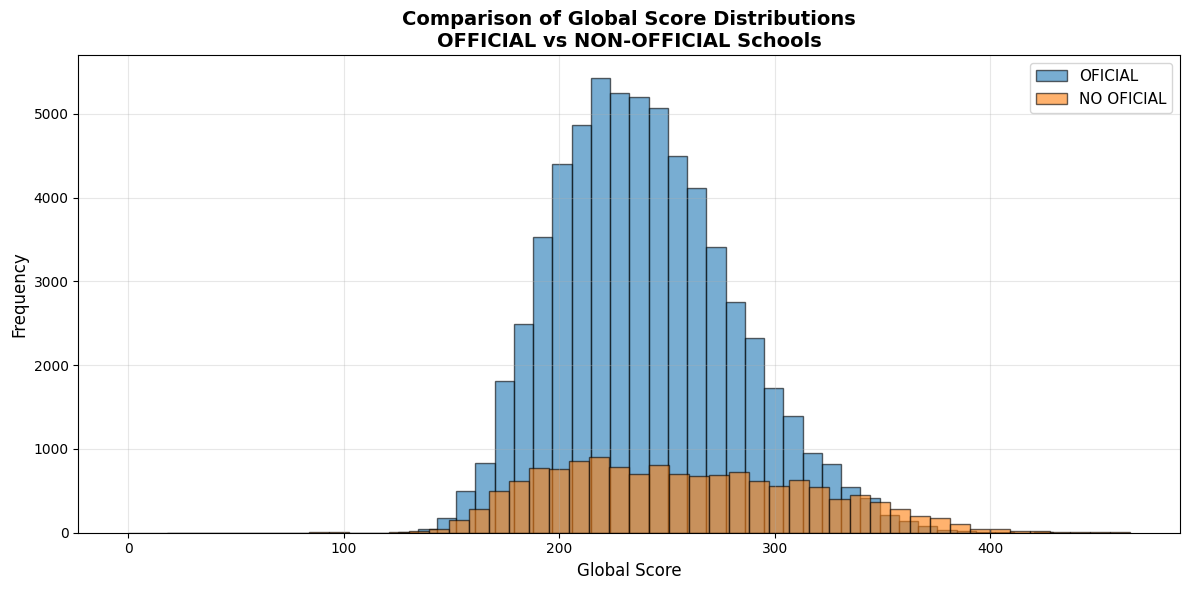

Figure 2: Overlapping histogram comparing the distributions of both school types.


In [24]:
# 6. Overlapping hist (to compare) (with help from Copilot)
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(official_scores, bins=50, alpha=0.6, label='OFICIAL', color='#1f77b4', edgecolor='black')
ax.hist(non_official_scores, bins=50, alpha=0.6, label='NO OFICIAL', color='#ff7f0e', edgecolor='black')

ax.set_xlabel('Global Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Comparison of Global Score Distributions\nOFFICIAL vs NON-OFFICIAL Schools', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Figure 2: Overlapping histogram comparing the distributions of both school types.")

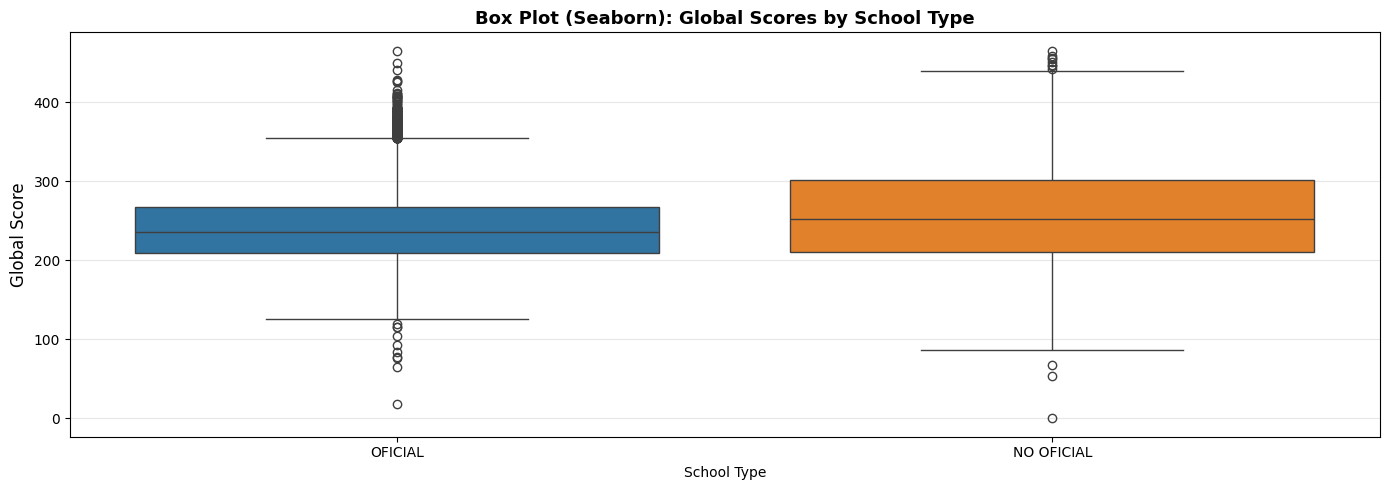

Figure 3: Box plots showing quartiles, median, and outliers for each school type.


In [25]:
# 7. Box plots - Global Scores by School Type (with help from Copilot)
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# Box plot
df_for_plot = pd.DataFrame({
    'School Type': ['OFICIAL']*len(official_scores) + ['NO OFICIAL']*len(non_official_scores),
    'Global Score': list(official_scores) + list(non_official_scores)
})

sns.boxplot(data=df_for_plot, x='School Type', y='Global Score', ax=axes, hue='School Type', palette=['#1f77b4', '#ff7f0e'])
axes.set_title('Box Plot (Seaborn): Global Scores by School Type', fontsize=13, fontweight='bold')
axes.set_ylabel('Global Score', fontsize=12)
axes.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Figure 3: Box plots showing quartiles, median, and outliers for each school type.")

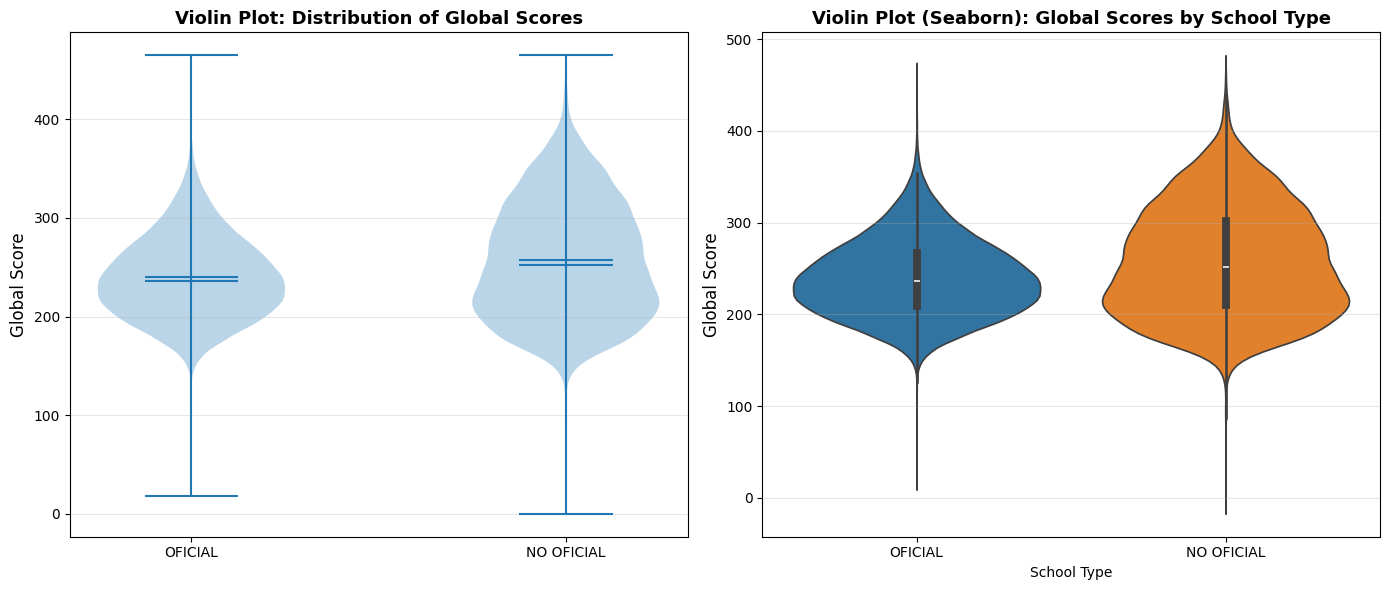

Figure 4: Violin plots showing the full distribution density of each school type.


In [31]:
# 8. Violin plots (with help from Copilot)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Violin plot 1
parts = axes[0].violinplot([official_scores, non_official_scores], positions=[1, 2], showmeans=True, showmedians=True)
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(['OFICIAL', 'NO OFICIAL'])
axes[0].set_ylabel('Global Score', fontsize=12)
axes[0].set_title('Violin Plot: Distribution of Global Scores', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Violin plot 2: Using seaborn
sns.violinplot(data=df_for_plot, x='School Type', y='Global Score', ax=axes[1], hue='School Type', palette=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Violin Plot (Seaborn): Global Scores by School Type', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Global Score', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Figure 4: Violin plots showing the full distribution density of each school type.")

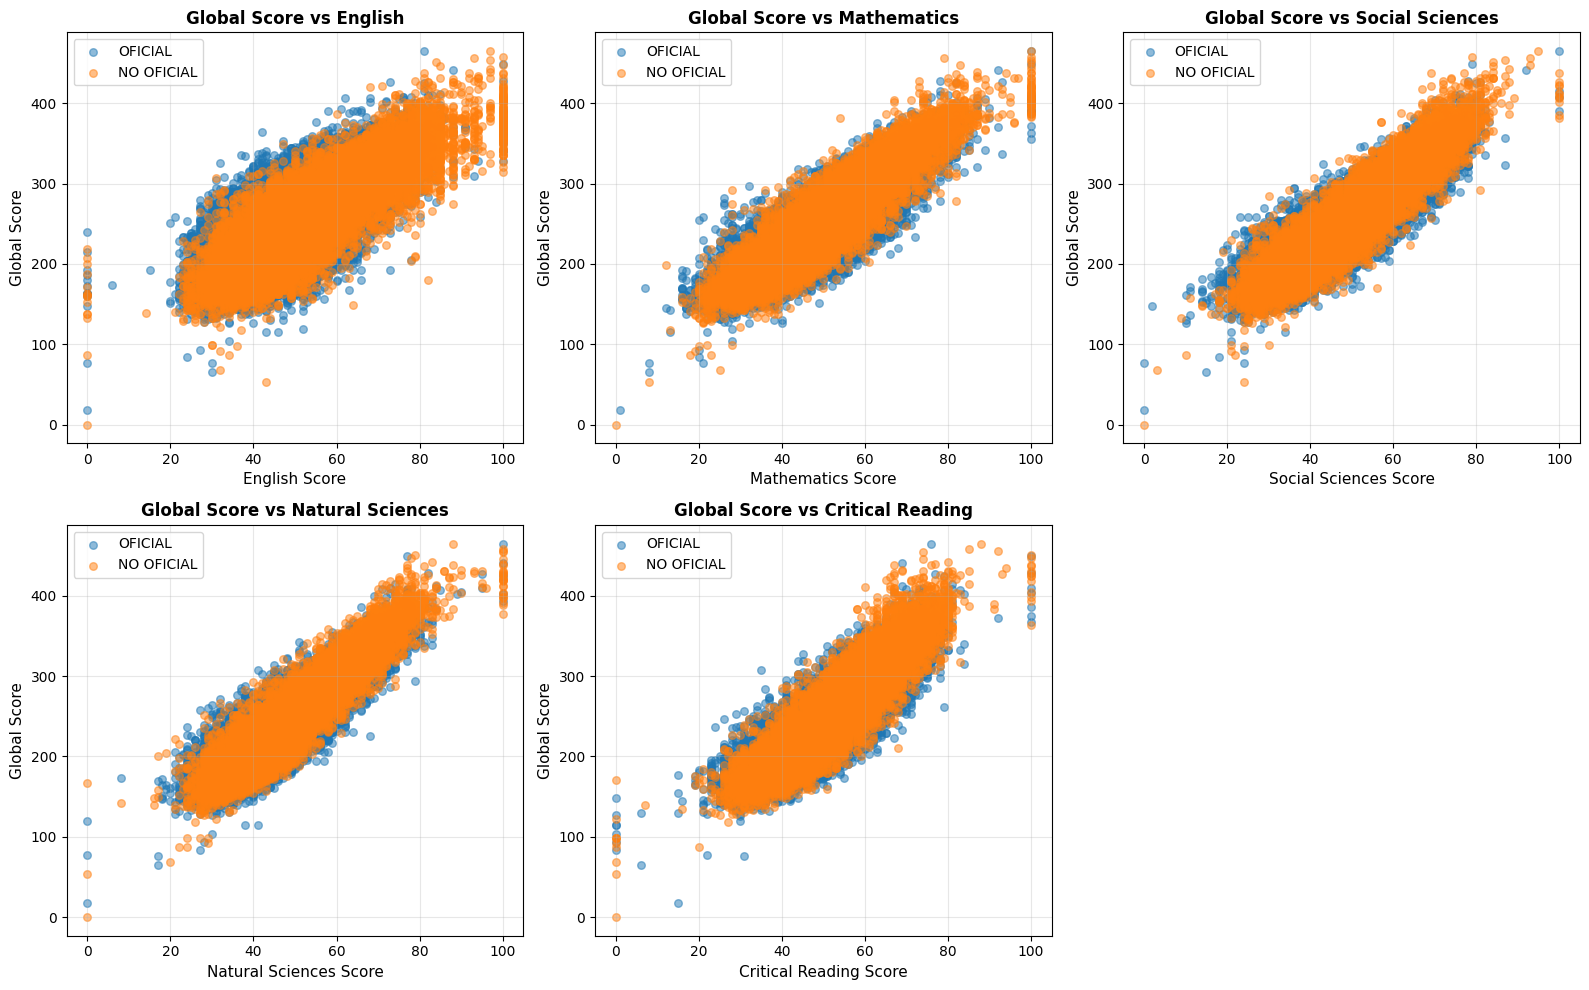

Figure 5: Scatter plots showing relationships between individual subject scores and global scores.


In [27]:
# 9. Scatter plots - Global Score vs Subject Scores (with help from Copilot)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

subject_columns = ['punt_ingles', 'punt_matematicas', 'punt_sociales_ciudadanas', 
                   'punt_c_naturales', 'punt_lectura_critica']
subject_labels = ['English', 'Mathematics', 'Social Sciences', 'Natural Sciences', 'Critical Reading']

for idx, (subject, label) in enumerate(zip(subject_columns, subject_labels)):
    official_mask = df['cole_naturaleza'] == 'OFICIAL'
    non_official_mask = df['cole_naturaleza'] == 'NO OFICIAL'
    
    axes[idx].scatter(df[official_mask][subject], df[official_mask]['punt_global'], 
                     alpha=0.5, s=30, label='OFICIAL', color='#1f77b4')
    axes[idx].scatter(df[non_official_mask][subject], df[non_official_mask]['punt_global'], 
                     alpha=0.5, s=30, label='NO OFICIAL', color='#ff7f0e')
    
    axes[idx].set_xlabel(f'{label} Score', fontsize=11)
    axes[idx].set_ylabel('Global Score', fontsize=11)
    axes[idx].set_title(f'Global Score vs {label}', fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

# Hide the last empty subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

print("Figure 5: Scatter plots showing relationships between individual subject scores and global scores.")

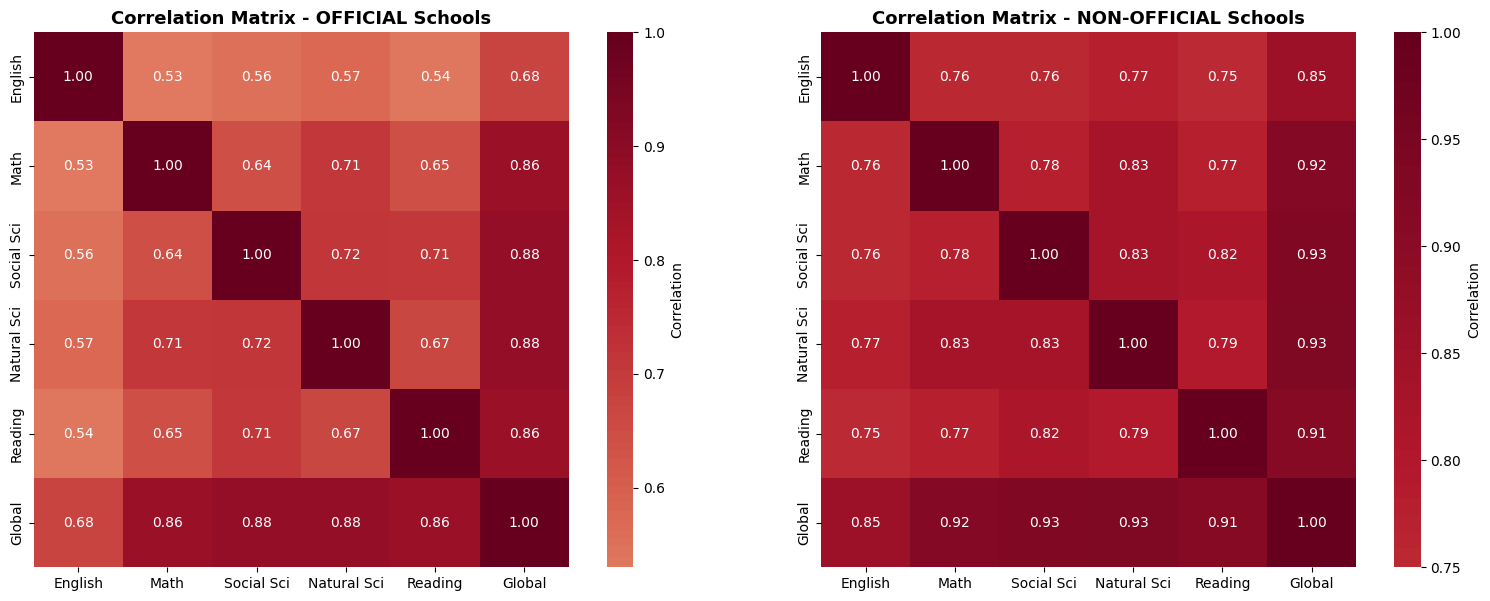

Figure 6: Correlation heatmaps showing relationships between subjects and global score.


In [28]:
# 10. Heatmpa - By School Type (with help from Copilot)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Features for correlation analysis
columns_for_corr = subject_columns + ['punt_global']

# OFFICIAL schools
official_data = df[df['cole_naturaleza'] == 'OFICIAL'][columns_for_corr].dropna()
corr_official = official_data.corr()

sns.heatmap(corr_official, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, ax=axes[0], cbar_kws={'label': 'Correlation'},
            xticklabels=['English', 'Math', 'Social Sci', 'Natural Sci', 'Reading', 'Global'],
            yticklabels=['English', 'Math', 'Social Sci', 'Natural Sci', 'Reading', 'Global'])
axes[0].set_title('Correlation Matrix - OFFICIAL Schools', fontsize=13, fontweight='bold')

# NON-OFFICIAL schools
non_official_data = df[df['cole_naturaleza'] == 'NO OFICIAL'][columns_for_corr].dropna()
corr_non_official = non_official_data.corr()

sns.heatmap(corr_non_official, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, ax=axes[1], cbar_kws={'label': 'Correlation'},
            xticklabels=['English', 'Math', 'Social Sci', 'Natural Sci', 'Reading', 'Global'],
            yticklabels=['English', 'Math', 'Social Sci', 'Natural Sci', 'Reading', 'Global'])
axes[1].set_title('Correlation Matrix - NON-OFFICIAL Schools', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("Figure 6: Correlation heatmaps showing relationships between subjects and global score.")